In [57]:
import numpy as np
import matplotlib.pyplot as plt
from spleaf import cov, term
from nskernel import NonStationaryKernel
import scipy.io as sp
import pandas as pd

# Local alias for the MultiSeriesKernel used in the other notebook
SHOKernel = term.SHOKernel
SimpleProductKernel = term.SimpleProductKernel
ErrorTerm = term.Error
InstrumentJitter = term.InstrumentJitter

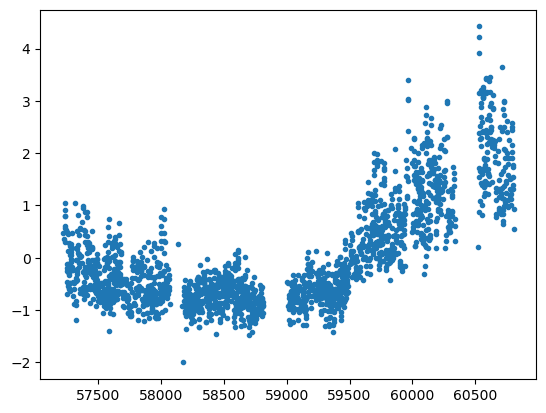

In [58]:
data_rhk = pd.read_csv("Solar Data/Analyse_summary.csv")

data_rhk = data_rhk[data_rhk["flag"] != 1]

arr_len = len(data_rhk)
tt = np.array(data_rhk["jdb"])
rhk = np.array(data_rhk["MHK_cleaned"])
rhk_err = np.array(data_rhk["MHK_cleaned_std"])

data_rv = pd.read_pickle('Solar Data/Analyse_ccf.p')['CCF_kitcat_mask_Sun']['matching_instrument']['table']
data_rv = data_rv.loc[data_rv.index.isin(data_rhk.index)]

rv = np.array(data_rv['rv'])
erv = np.sqrt(np.array(data_rv['rv_std'])**2 + (np.ones_like(rv) * 0.0005)**2)


rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

rhk_mean = np.mean(rhk)
rhk_std  = np.std(rhk)
rhk_norm = (rhk - rhk_mean) / rhk_std

# # ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
rhk_err_norm = rhk_err / rhk_std


T = [tt,tt]
Y = [rv_norm,rhk_norm]
Yerr = [erv_norm,rhk_err_norm]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

plt.plot(tt, rv_norm, ".")


In [59]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

In [60]:
def alpha(t, pcyc, phi, k, c):
    # constraint |k| <= 1/3
    # k = (1.0 / 3.0) * np.tanh(k_raw)
    x = (2.0 * np.pi / pcyc) * t + phi

    fc = np.sin(x + k * np.sin(x))  # in [-1, 1]

    # linear normalization to [C, 1]
    return ((1.0 - c) / 2.0) * (fc + 1.0) + c

def alpha_grad(t, pcyc, phi, k, c):
    
    omega = 2.0 * np.pi / pcyc
    x = omega * t + phi

    # k is provided directly (assumed already constrained to |k| <= 1/3)
    # (previously: k = (1.0 / 3.0) * np.tanh(k_raw))

    inner = x + k * np.sin(x)
    s_inner = np.sin(inner)
    c_inner = np.cos(inner)

    scale = (1.0 - c) / 2.0

    # d(inner)/dx
    d_inner_dx = 1.0 + k * np.cos(x)

    # d alpha / d s
    d_alpha_ds = scale

    # chain: d alpha / d inner
    d_alpha_dinner = d_alpha_ds * c_inner

    grads = {}

    # ----- derivative wrt phi -----
    # dx/dphi = 1
    grads['phi'] = d_alpha_dinner * d_inner_dx

    # ----- derivative wrt pcyc -----
    # omega = 2π/pcyc
    domega_dp = -2.0 * np.pi / (pcyc ** 2)
    dx_dp = domega_dp * t
    grads['pcyc'] = d_alpha_dinner * d_inner_dx * dx_dp

    # ----- derivative wrt k -----
    # k is the input directly, so dk/dk = 1
    d_inner_dk = np.sin(x)
    grads['k'] = d_alpha_dinner * d_inner_dk

    # ----- derivative wrt c -----
    # alpha = scale*(s+1) + c
    # scale = (1-C)/2
    # d alpha / dC = -(1/2)*(s+1) + 1
    grads['c'] = -0.5 * (s_inner + 1.0) + 1.0

    return grads


In [5]:
map_sample = np.load("sun_map_sample.npy")

rv_jit, rhk_jit, pcyc, phi, k_param, c_param, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = map_sample

stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 20.0
Q = 1.0


C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rv_jit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhk_jit),
  gp=term.SimpleProductKernel(
      nonstat=NonStationaryKernel(alpha, alpha_grad, pcyc=pcyc, phi = phi, k = k_param, c = c_param),
      rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index, 
        np.ones(2) * stds, 
        np.array([stds[0], 0.0])
    ),
  )
)

fitted = [k for k, key in enumerate(C.param) if key != 'gp.rot_sig' and key != "gp.rot_beta_1"]  
params = [C.param[k] for k in fitted]
C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['gp.rot_beta_1'])
C.set_param([np.var(y_full)], ['gp.rot_sig'])

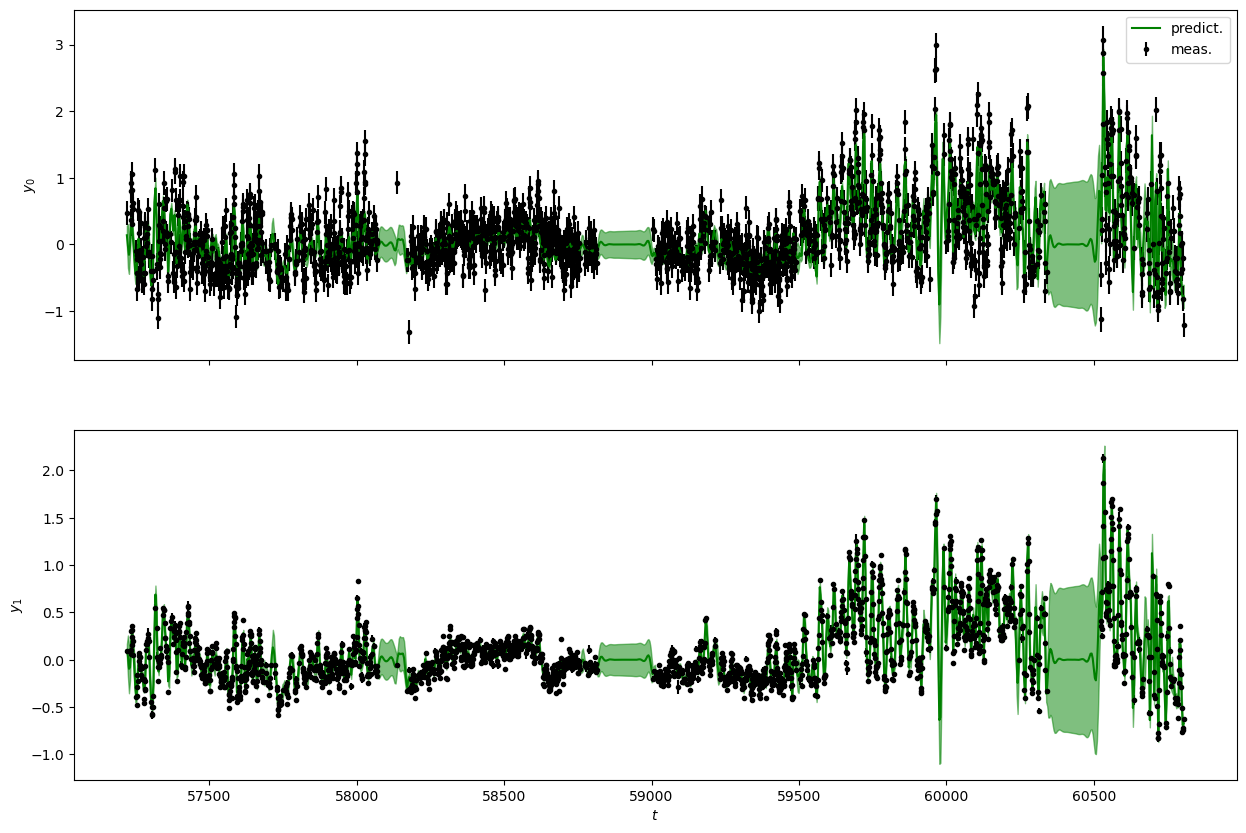

In [6]:
tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))

fc = alpha(t_full, map_sample[2], map_sample[3], map_sample[4],map_sample[5])
fc_unnorm = (fc - map_sample[5]) / ((1.0 - map_sample[5]) / 2.0) - 1
y_model = y_full.copy()

y_model[series_index[0]] -= map_sample[-4]*fc_unnorm[series_index[0]] + map_sample[-2]
y_model[series_index[1]] -= map_sample[-3]*fc_unnorm[series_index[1]] + map_sample[-1]

for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  
  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = y_model[series_index[k]] - mu_res
  else:
    res_rhk = y_model[series_index[k]] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(map_sample[-4]*fc_unnorm[series_index[0]]+map_sample[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(map_sample[-3]*fc_unnorm[series_index[1]]+map_sample[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()




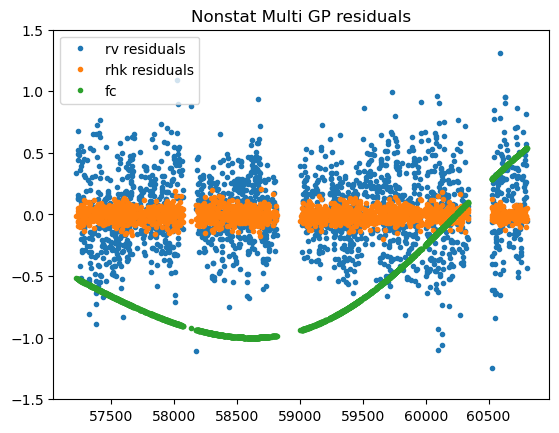

In [7]:
plt.figure()
plt.title("Nonstat Multi GP residuals")
plt.plot(T[0], res_rv, ".", label='rv residuals')
plt.plot(T[1], res_rhk, ".", label='rhk residuals')
plt.plot(T[0], fc_unnorm[series_index[0]], ".", label='fc')
plt.ylim(-1.5,1.5)
plt.legend()
plt.show()

In [8]:
res_rv = 0
res_rhk = 0

rv_true = []
rv_pred = []
rv_var = []
# rv_means = []

rhk_true = []
rhk_pred = []
rhk_var = []
# rhk_means = []

t_is = []


    # now loop over points *in series k* and leave each one out
for local_i in range(len(T[0])-3):

    T_train = np.delete(T, [local_i, local_i+1], axis=1)
    Y_train = np.delete(Y, [local_i, local_i+1], axis=1)
    Yerr_train = np.delete(Yerr, [local_i, local_i+1], axis=1)

    t_train_full, y_train_full, yerr_train_full, series_index_train_full = cov.merge_series(T_train, Y_train, Yerr_train)

    fc_train = alpha(t_train_full, map_sample[2], map_sample[3], map_sample[4], map_sample[5])
    fc_unnorm_train = (fc_train - map_sample[5]) / ((1.0 - map_sample[5]) / 2.0) - 1

    y_model_train_full = y_train_full.copy()
    y_model_train_full[series_index_train_full[0]] -= map_sample[-4] * fc_unnorm_train[series_index_train_full[0]] + map_sample[-2]
    y_model_train_full[series_index_train_full[1]] -= map_sample[-3] * fc_unnorm_train[series_index_train_full[1]] + map_sample[-1]
        
    t_i = T[0][local_i:local_i+2]  
    rv_i = Y[0][local_i:local_i+2] - (map_sample[-4]*fc_unnorm[series_index[0]]+map_sample[-2])[local_i:local_i+2] 
    rhk_i = Y[1][local_i:local_i+2] - (map_sample[-3]*fc_unnorm[series_index[1]]+map_sample[-1])[local_i:local_i+2]

    # print(rv_i==y_model[series_index[0][local_i:local_i+2]])
    t_is.append(t_i)
    rv_true.append(rv_i)
    rhk_true.append(rhk_i)

    C = cov.Cov(
    t_train_full,
    err=term.Error(yerr_train_full),
    rv_jit=term.InstrumentJitter(series_index_train_full[0], rv_jit),
    rhk_jit=term.InstrumentJitter(series_index_train_full[1], rhk_jit),
    gp=term.SimpleProductKernel(
    nonstat=NonStationaryKernel(alpha, alpha_grad, pcyc=pcyc, phi = phi, k = k_param, c = c_param),
    rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index_train_full, 
    np.ones(2) * stds, 
    np.array([stds[0], 0.0])
        ),
    )
    )

    C.set_param(map_sample[:len(params)], params)
    C.set_param([0.0], ['gp.rot_beta_1'])
    C.set_param([np.var(y_full)], ['gp.rot_sig'])

    for k in range(2):

        C.kernel['gp'].set_conditional_coef(series_id=k)
        # Condition on training targets (with the single point removed) and predict at t_i
        mu_i, var_i = C.conditional(y_model_train_full, t_i, calc_cov='diag')
        # store the predicted mean/var for this held-out point
        
        if k == 0:
            rv_pred.append(mu_i)
            rv_var.append(var_i)
            resid = rv_i - mu_i
            res_rv += np.sum(resid ** 2)
        else:
            rhk_pred.append(mu_i)
            rhk_var.append(var_i)
            resid = rhk_i - mu_i
            res_rhk += np.sum(resid ** 2)


print(f"LOO residual sum of squares for RV: {res_rv:.4f}")
print(f"LOO residual sum of squares for RHK: {res_rhk:.4f}")


LOO residual sum of squares for RV: 445.7110
LOO residual sum of squares for RHK: 40.7007


Making the standard multi-GP fit

In [5]:
from scipy.optimize import fmin_l_bfgs_b


stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 28.0
Q = 1.3

rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

# a1, a2, c, pcyc = 0.5, -6.1, 2.0, 2500.0

pcyc, phi, k, c = 8000.0, -np.pi/2, 0.1, 0.1


C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index, 
        np.ones(2) * stds, 
        np.array([stds[0], 0.0])
    ),
  )

In [6]:


rvjit_max = 5*stds[0]
rhkjit_max = 5*stds[1]

prot_min = 17.0
prot_max = 30.0
Q_min = 0.7
Q_max = 1.7

alpha_0_max = 5*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 5*stds[0]
beta_1_max  = 5*stds[1]

pcyc_min = 7000.0
pcyc_max = 9000.0

gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]

bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      # rot.beta_1
    (pcyc_min, pcyc_max),
    (0,np.pi*2),
    (-0.4,0.4),  # k
    (0.01,0.99), 
    (0.0, gamma_0_max*2+2),         # rot.gamma_0
    (0.0, gamma_1_max*2+2),         # rot.gamma_1
    (-gamma_0_max, gamma_0_max),         # delta_0 (offset for series 0)
    (-gamma_1_max, gamma_1_max),    # c

]

map_sample = np.load("sun_map_sample.npy")
          
fitted = [k for k, key in enumerate(C.param) if key != 'rot.sig' and key != "rot.beta_1"]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)
x0 = np.append(x0,[map_sample[2],map_sample[3],map_sample[4],map_sample[5],0.0,0.0,0.0,0.0])

def negloglike(x, y, C):
  
  C.set_param(x[:len(params)], params)
  fc = alpha(t_full, x[7],x[8],x[9],x[10])
  fc_unnorm = (fc - x[10]) / ((1.0 - x[10]) / 2.0) - 1
  fc_grads = alpha_grad(t_full ,x[7],x[8],x[9],x[10])
  y_model = y.copy()
  y_model[series_index[0]] -= (x[-4]*fc_unnorm[series_index[0]] + x[-2])
  y_model[series_index[1]] -= (x[-3]*fc_unnorm[series_index[1]] + x[-1])
  # gradient
  nll = -C.loglike(y_model)

  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  # gradients wrt gamma (scale of fc)
  grad_gamma_0 = np.sum(dL_dy[series_index[0]] * fc_unnorm[series_index[0]])
  grad_gamma_1 = np.sum(dL_dy[series_index[1]] * fc_unnorm[series_index[1]])
  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy[series_index[0]])
  grad_delta_1 = np.sum(dL_dy[series_index[1]])

  grad_pcyc = np.sum(dL_dy[series_index[0]] * x[-4] * fc_grads['pcyc'][series_index[0]]) + np.sum(dL_dy[series_index[1]] * x[-3] * fc_grads['pcyc'][series_index[1]])
  grad_phi = np.sum(dL_dy[series_index[0]] * x[-4] * fc_grads['phi'][series_index[0]]) + np.sum(dL_dy[series_index[1]] * x[-3] * fc_grads['phi'][series_index[1]])
  grad_k_alpha = np.sum(dL_dy[series_index[0]] * x[-4] * fc_grads['k'][series_index[0]]) + np.sum(dL_dy[series_index[1]] * x[-3] * fc_grads['k'][series_index[1]])
  grad_c = np.sum(dL_dy[series_index[0]] * x[-4] * fc_grads['c'][series_index[0]]) + np.sum(dL_dy[series_index[1]] * x[-3] * fc_grads['c'][series_index[1]])
  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_pcyc, grad_phi, grad_k_alpha, grad_c, grad_gamma_0, grad_gamma_1, grad_delta_0, grad_delta_1])])

  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])


print(params)
print(xbest)

['rv_jit.sig', 'rhk_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0']
[2.82307022e-01 0.00000000e+00 2.58530961e+01 7.00000000e-01
 8.54470367e-01 7.65596701e-01 6.24272701e-01 7.88475380e+03
 2.43792368e+00 3.11348972e-01 1.07487073e-01 2.05206497e+00
 2.15390358e+00 1.08643028e+00 1.15025358e+00]


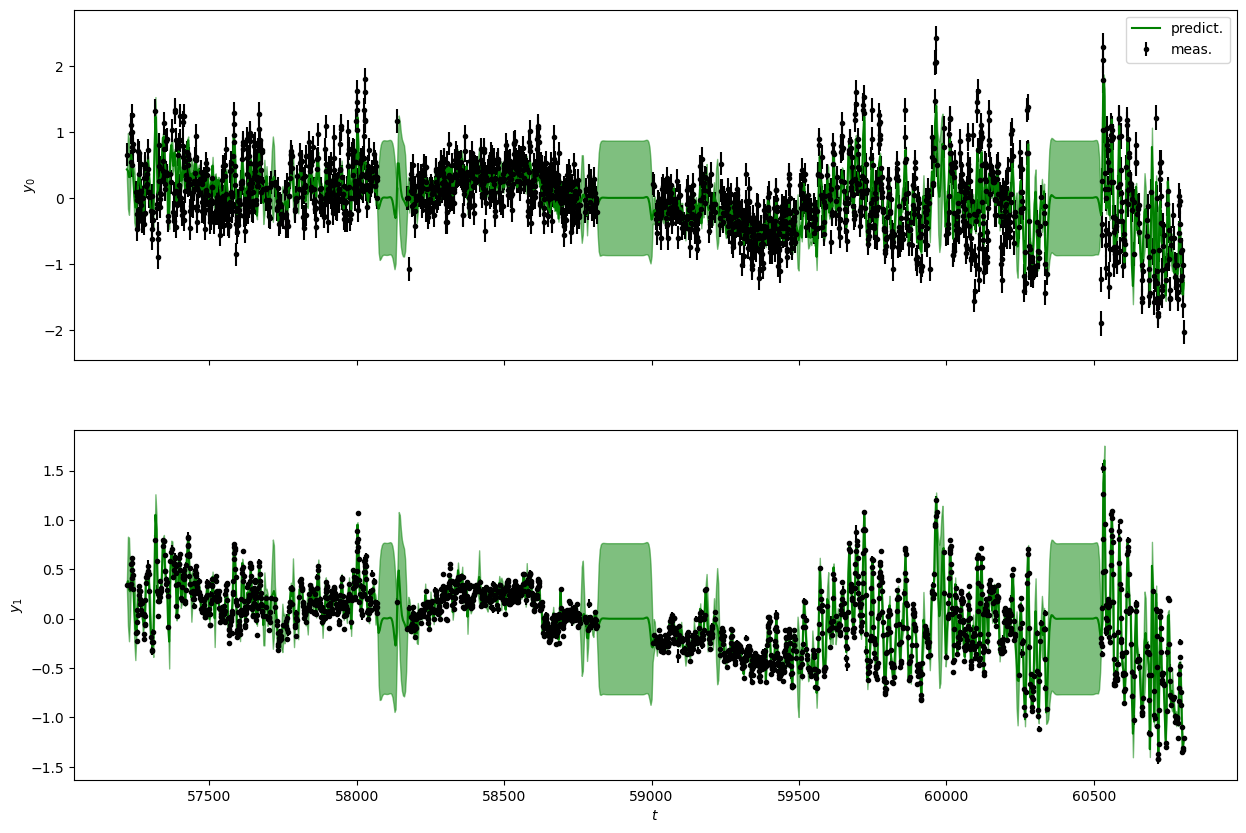

In [7]:

tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['rot'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)

  fc = alpha(t_full, xbest[7],xbest[8],xbest[9],xbest[10])
  fc_unnorm = (fc - xbest[10]) / ((1.0 - xbest[10]) / 2.0) - 1
  y_model = y_full.copy()
  y_model[series_index[0]] -= (xbest[-4]*fc_unnorm[series_index[0]] + xbest[-2])
  y_model[series_index[1]] -= (xbest[-3]*fc_unnorm[series_index[1]] + xbest[-1])

  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(xbest[-4]*fc_unnorm[series_index[0]]+xbest[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(xbest[-3]*fc_unnorm[series_index[1]]+xbest[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

In [8]:
import emcee


def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, pcyc, phi, k_raw, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    rv_jit, rhk_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, pcyc, phi, k, c, gamma_0, gamma_1, delta_0, delta_1 = theta
    phi = phi % (2*np.pi)
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and pcyc_min < pcyc < pcyc_max and 0 < phi < np.pi*2 and -0.4< k < 0.4 and 0.01 < c < 0.9 and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and 0.0 < gamma_0 < gamma_0_max and 0.0 < gamma_1 < gamma_0_max and -gamma_0_max < delta_0 < gamma_0_max and -gamma_0_max < delta_1 < gamma_0_max:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
# x0 = map_sample[[0,1,6,7,8,9,10]]
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);



[2.82307022e-01 0.00000000e+00 2.58530961e+01 7.00000000e-01
 8.54470367e-01 7.65596701e-01 6.24272701e-01 7.88475380e+03
 2.43792368e+00 3.11348972e-01 1.07487073e-01 2.05206497e+00
 2.15390358e+00 1.08643028e+00 1.15025358e+00]
-inf


  0%|          | 0/2000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [03:48<00:00,  8.76it/s]


['rv_jit.sig', 'rhk_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0', 'pcyc', 'phi', 'k', 'c', 'gamma_0', 'gamma_1', 'delta_0', 'delta_1']


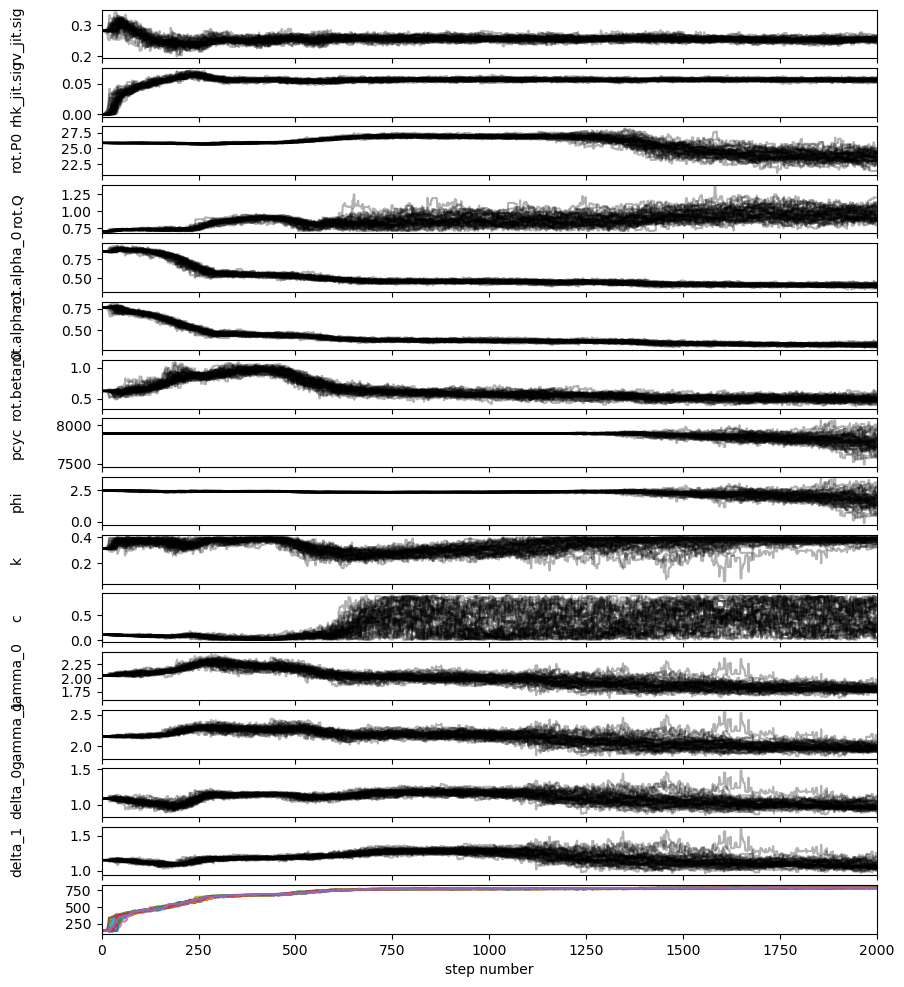

In [12]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 9, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

labels = params + ['pcyc', 'phi', 'k', 'c', 'gamma_0', 'gamma_1', 'delta_0', 'delta_1']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

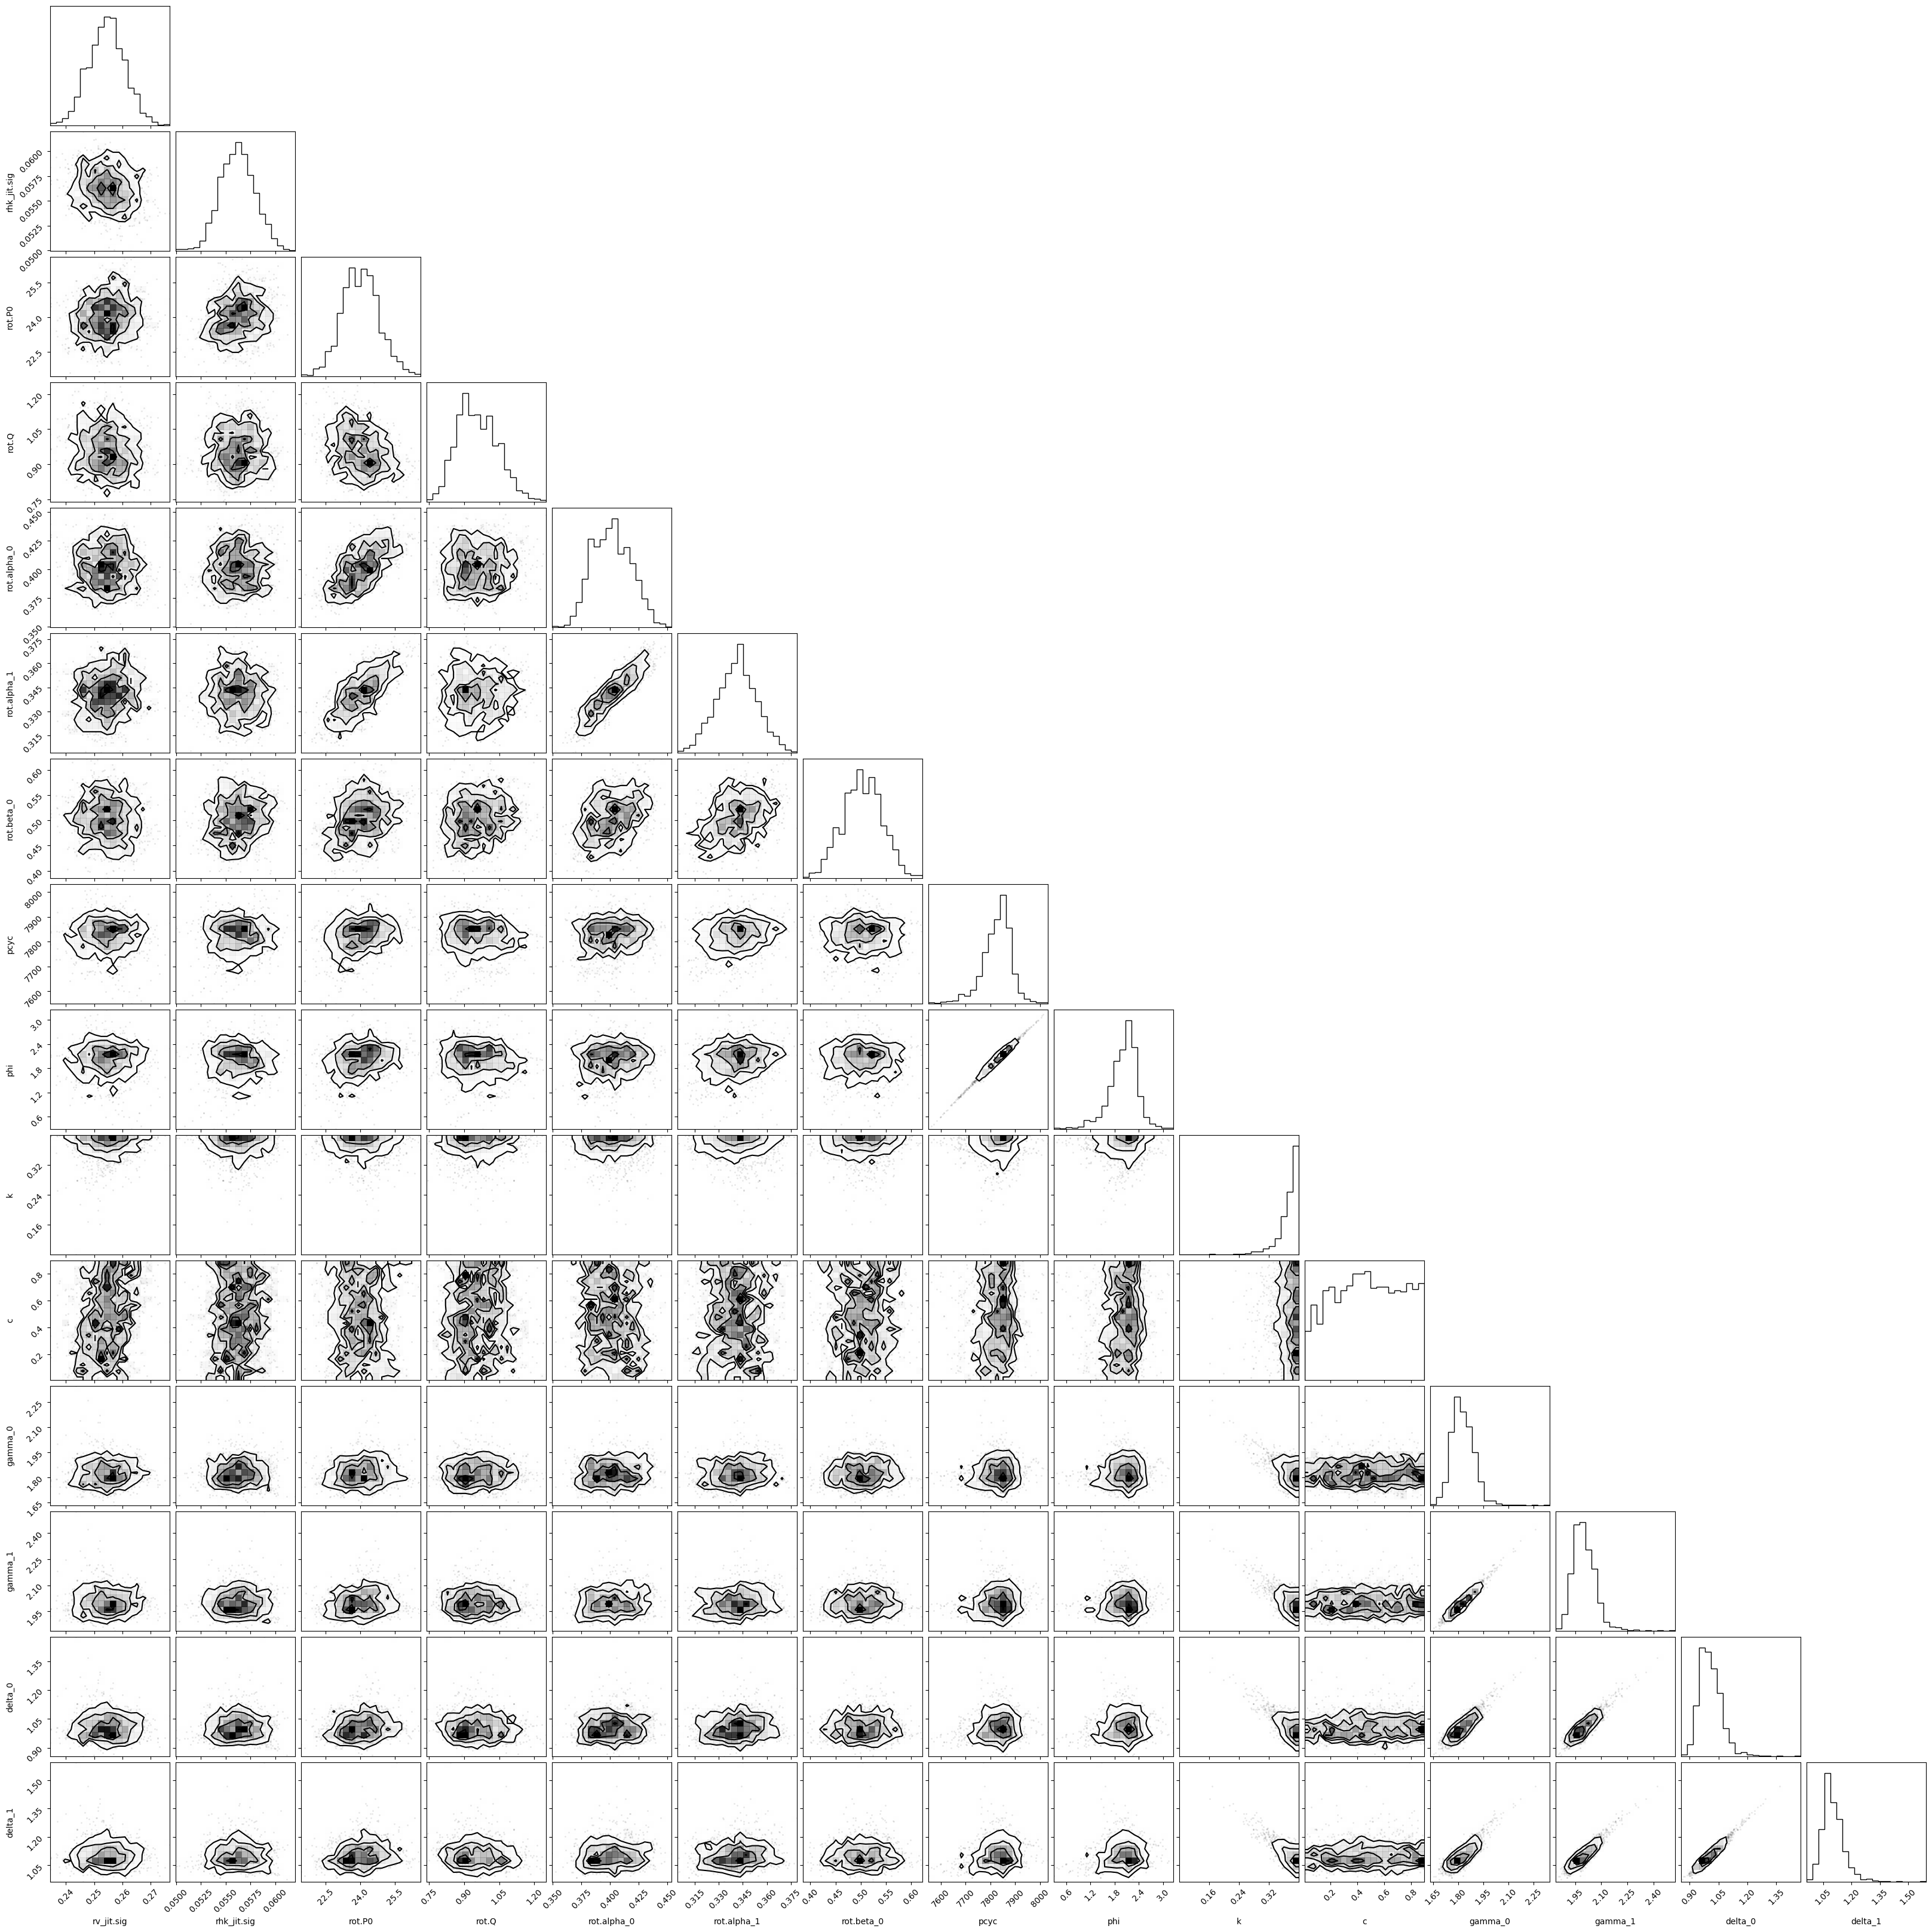

In [13]:
import corner

flat_samples = sampler.get_chain(discard=1500, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



In [14]:
burn = 1500 
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

# np.save("sun_map_sample_simpleGP_fixedalphagrad.npy", map_sample)

MAP index (in flattened, post-burn chain): 20012
MAP log-posterior: 794.5027855554235
MAP sample (theta): [2.52699754e-01 5.50223984e-02 2.33330876e+01 9.51540925e-01
 3.97409262e-01 3.37308994e-01 5.07770474e-01 7.64178610e+03
 8.94476463e-01 3.91070209e-01 7.09589064e-01 1.77770714e+00
 1.94250357e+00 9.28179396e-01 1.01322590e+00]


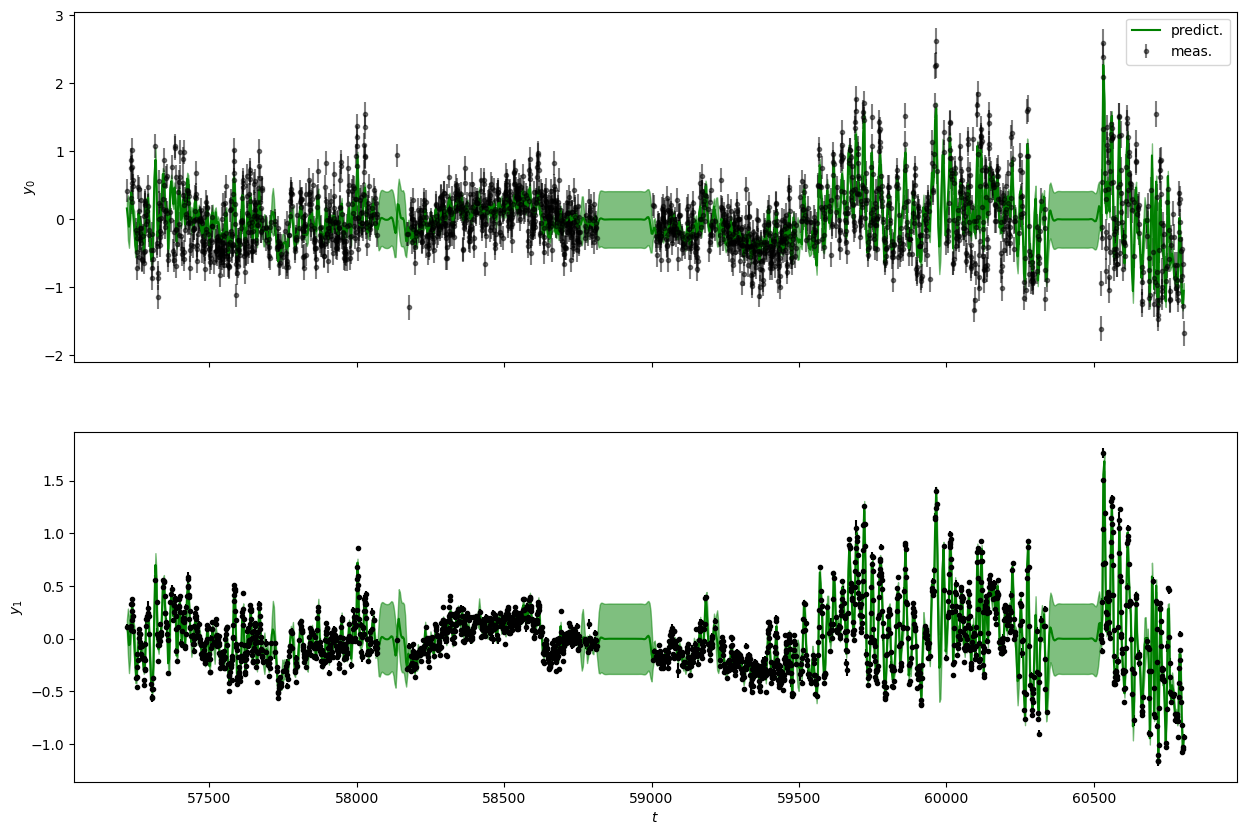

In [15]:
map_sample = np.load("sun_map_sample_simpleGP_fixedalphagrad.npy")

C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])
C.set_param([np.var(y_full)], ['rot.sig'])


tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['rot'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  # use MAP sample for modulation and offsets
  fc = alpha(t_full, map_sample[7], map_sample[8], map_sample[9],map_sample[10])
  fc_unnorm = (fc - map_sample[10]) / ((1.0 - map_sample[10]) / 2.0) - 1
  y_model = y_full.copy()
  # map_sample tail: [..., gamma_0, gamma_1, delta_0, delta_1]
  y_model[series_index[0]] -= map_sample[-4]*fc_unnorm[series_index[0]] + map_sample[-2]
  y_model[series_index[1]] -= map_sample[-3]*fc_unnorm[series_index[1]] + map_sample[-1]
  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = y_model[series_index[k]] - mu_res
  else:
    res_rhk = y_model[series_index[k]] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(map_sample[-4]*fc_unnorm[series_index[0]]+map_sample[-2]), Yerr[k], fmt='.', color='k', label='meas.',alpha=0.5)
  if k == 1:
    ax.errorbar(T[k], Y[k]-(map_sample[-3]*fc_unnorm[series_index[1]]+map_sample[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

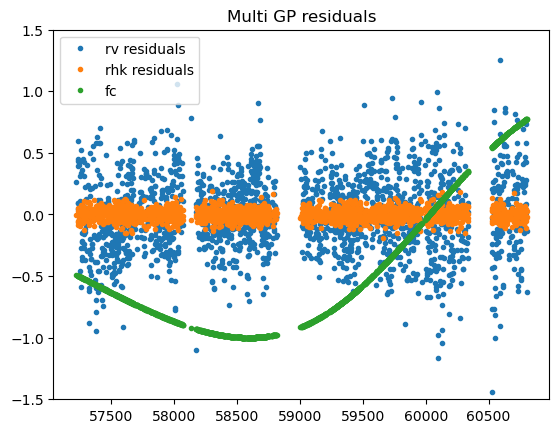

In [16]:
plt.figure()
plt.title("Multi GP residuals")
plt.plot(T[0], res_rv, ".", label='rv residuals')
plt.plot(T[1], res_rhk, ".", label='rhk residuals')
plt.plot(T[0], fc_unnorm[series_index[0]], ".", label='fc')
plt.ylim(-1.5,1.5)
plt.legend()
plt.show()

In [19]:
map_sample = np.load("sun_map_sample_simpleGP_fixedalphagrad.npy")

rv_jit, rhk_jit, pcyc, phi, k_param, c_param, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = map_sample

res_rv = 0
res_rhk = 0

rv_true = []
rv_pred = []
rv_var = []
# rv_means = []

rhk_true = []
rhk_pred = []
rhk_var = []
# rhk_means = []

t_is = []

fc = alpha(t_full, map_sample[7], map_sample[8], map_sample[9],map_sample[10])
fc_unnorm = (fc - map_sample[10]) / ((1.0 - map_sample[10]) / 2.0) - 1

    # now loop over points *in series k* and leave each one out
for local_i in range(len(T[0])-3):

    T_train = np.delete(T, [local_i, local_i+1], axis=1)
    Y_train = np.delete(Y, [local_i, local_i+1], axis=1)
    Yerr_train = np.delete(Yerr, [local_i, local_i+1], axis=1)

    t_train_full, y_train_full, yerr_train_full, series_index_train_full = cov.merge_series(T_train, Y_train, Yerr_train)

    fc_train = alpha(t_train_full, map_sample[7], map_sample[8], map_sample[9], map_sample[10])
    fc_unnorm_train = (fc_train - map_sample[10]) / ((1.0 - map_sample[10]) / 2.0) - 1

    y_model_train_full = y_train_full.copy()
    y_model_train_full[series_index_train_full[0]] -= map_sample[-4] * fc_unnorm_train[series_index_train_full[0]] + map_sample[-2]
    y_model_train_full[series_index_train_full[1]] -= map_sample[-3] * fc_unnorm_train[series_index_train_full[1]] + map_sample[-1]
        
    t_i = T[0][local_i:local_i+2]  
    rv_i = Y[0][local_i:local_i+2] - (map_sample[-4]*fc_unnorm[series_index[0]]+map_sample[-2])[local_i:local_i+2] 
    rhk_i = Y[1][local_i:local_i+2] - (map_sample[-3]*fc_unnorm[series_index[1]]+map_sample[-1])[local_i:local_i+2]

    # print(rv_i==y_model[series_index[0][local_i:local_i+2]])
    t_is.append(t_i)
    rv_true.append(rv_i)
    rhk_true.append(rhk_i)

    C = cov.Cov(
    t_train_full,
    err=term.Error(yerr_train_full),
    rv_jit=term.InstrumentJitter(series_index_train_full[0], rv_jit),
    rhk_jit=term.InstrumentJitter(series_index_train_full[1], rhk_jit),
    rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index_train_full, 
    np.ones(2) * stds, 
    np.array([stds[0], 0.0])
        ),
    )

    C.set_param(map_sample[:len(params)], params)
    C.set_param([0.0], ['rot.beta_1'])
    C.set_param([np.var(y_full)], ['rot.sig'])

    for k in range(2):

        C.kernel['rot'].set_conditional_coef(series_id=k)
        # Condition on training targets (with the single point removed) and predict at t_i
        mu_i, var_i = C.conditional(y_model_train_full, t_i, calc_cov='diag')
        # store the predicted mean/var for this held-out point
        
        if k == 0:
            rv_pred.append(mu_i)
            rv_var.append(var_i)
            resid = rv_i - mu_i
            res_rv += np.sum(resid ** 2)
        else:
            rhk_pred.append(mu_i)
            rhk_var.append(var_i)
            resid = rhk_i - mu_i
            res_rhk += np.sum(resid ** 2)


print(f"LOO residual sum of squares for RV: {res_rv:.4f}")
print(f"LOO residual sum of squares for RHK: {res_rhk:.4f}")

LOO residual sum of squares for RV: 438.2403
LOO residual sum of squares for RHK: 40.6620


Making the multi GP with constant mean

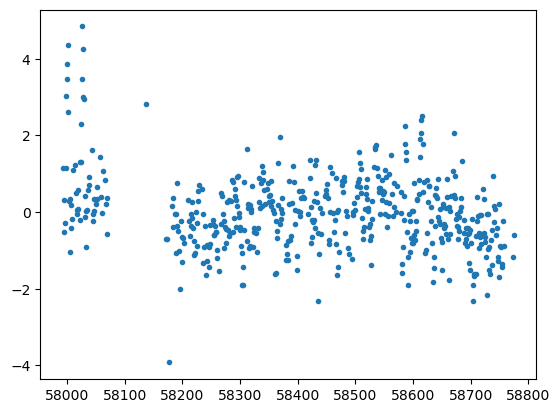

In [72]:
cutoff = 500

data_rhk = pd.read_csv("Solar Data/Analyse_summary.csv")

data_rhk = data_rhk[data_rhk["flag"] != 1]

arr_len = len(data_rhk)
tt = np.array(data_rhk["jdb"])[cutoff:cutoff+500]
rhk = np.array(data_rhk["MHK_cleaned"])[cutoff:cutoff+500]
rhk_err = np.array(data_rhk["MHK_cleaned_std"])[cutoff:cutoff+500]

data_rv = pd.read_pickle('Solar Data/Analyse_ccf.p')['CCF_kitcat_mask_Sun']['matching_instrument']['table']
data_rv = data_rv.loc[data_rv.index.isin(data_rhk.index)]

rv = np.array(data_rv['rv'])[cutoff:cutoff+500]
erv = np.sqrt(np.array(data_rv['rv_std'])[cutoff:cutoff+500]**2 + (np.ones_like(rv) * 0.0005)**2)


rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

rhk_mean = np.mean(rhk)
rhk_std  = np.std(rhk)
rhk_norm = (rhk - rhk_mean) / rhk_std

# # ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
rhk_err_norm = rhk_err / rhk_std


T = [tt,tt]
Y = [rv_norm,rhk_norm]
Yerr = [erv_norm,rhk_err_norm]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

plt.plot(tt, rv_norm, ".")

In [73]:
from scipy.optimize import fmin_l_bfgs_b


stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 28.0
Q = 1.3

rvjit = stds[0]
rhkjit = stds[1]


C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index, 
        np.ones(2) * stds, 
        np.array([stds[0], 0.0])
    ),
  )

In [74]:


rvjit_max = 5*stds[0]
rhkjit_max = 5*stds[1]

prot_min = 15.0
prot_max = 100.0
Q_min = 0.001
Q_max = 3.0

alpha_0_max = 5*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 5*stds[0]
beta_1_max  = 5*stds[1]


gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]

bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      # rot.beta_1
   
    (-gamma_0_max, gamma_0_max),         # delta_0 (offset for series 0)
    (-gamma_1_max, gamma_1_max),    # c

]
          
fitted = [k for k, key in enumerate(C.param) if key != 'rot.sig' and key != "rot.beta_1"]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)
x0 = np.append(x0,[0.0,0.0])

def negloglike(x, y, C):
  
  C.set_param(x[:len(params)], params)
  y_model = y.copy()
  y_model[series_index[0]] -=  x[-2]
  y_model[series_index[1]] -= x[-1]
  # gradient
  nll = -C.loglike(y_model)

  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy[series_index[0]])
  grad_delta_1 = np.sum(dL_dy[series_index[1]])

  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_delta_0, grad_delta_1])])

  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])


print(params)
print(xbest)

['rv_jit.sig', 'rhk_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0']
[ 5.67236516e-01  3.49945440e-01  2.96484351e+01  4.54941931e-01
  4.75313992e-01  8.74825405e-01  1.74877801e+00 -4.36578209e-03
 -2.41136964e-02]


In [75]:
import emcee


def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, pcyc, phi, k_raw, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    rv_jit, rhk_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, delta_0, delta_1 = theta
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and -gamma_0_max < delta_0 < gamma_0_max and -gamma_0_max < delta_1 < gamma_0_max:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
# x0 = map_sample[[0,1,6,7,8,9,10]]
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);



[ 5.67236516e-01  3.49945440e-01  2.96484351e+01  4.54941931e-01
  4.75313992e-01  8.74825405e-01  1.74877801e+00 -4.36578209e-03
 -2.41136964e-02]
0.0


100%|██████████| 2000/2000 [00:43<00:00, 46.09it/s]


['rv_jit.sig', 'rhk_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0', 'delta_0', 'delta_1']


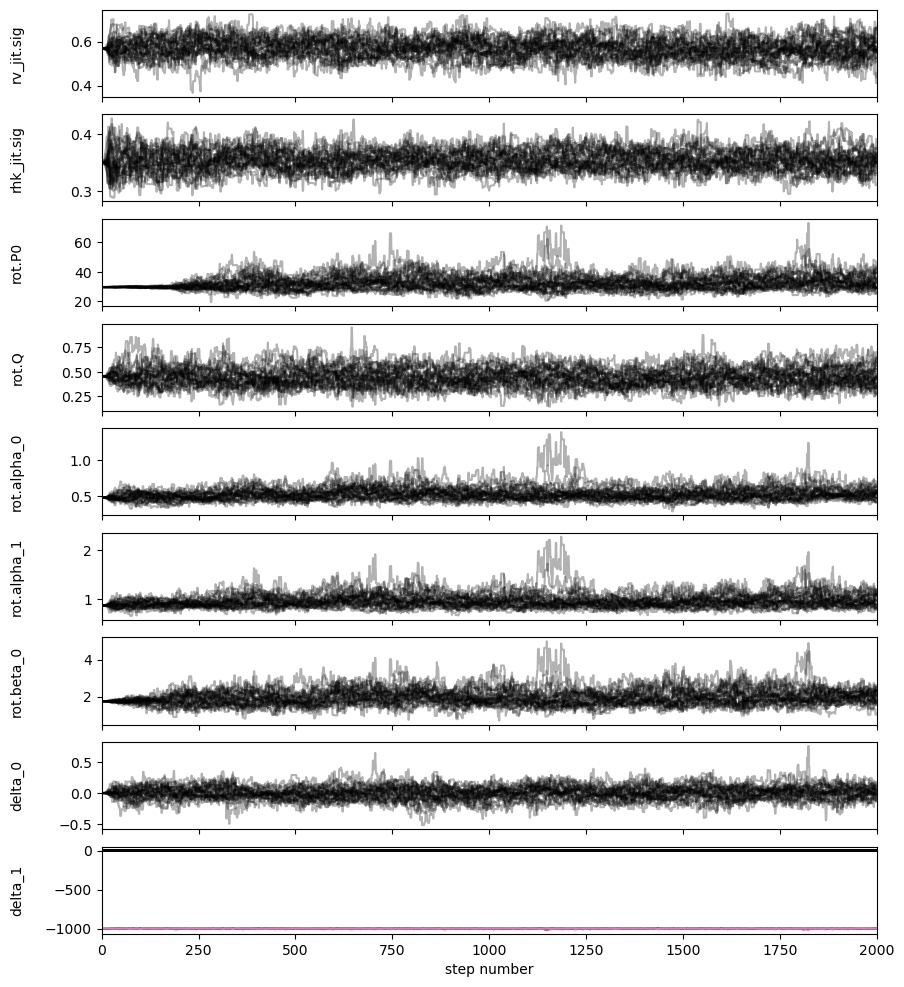

In [76]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 2, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

labels = params + ['delta_0', 'delta_1']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

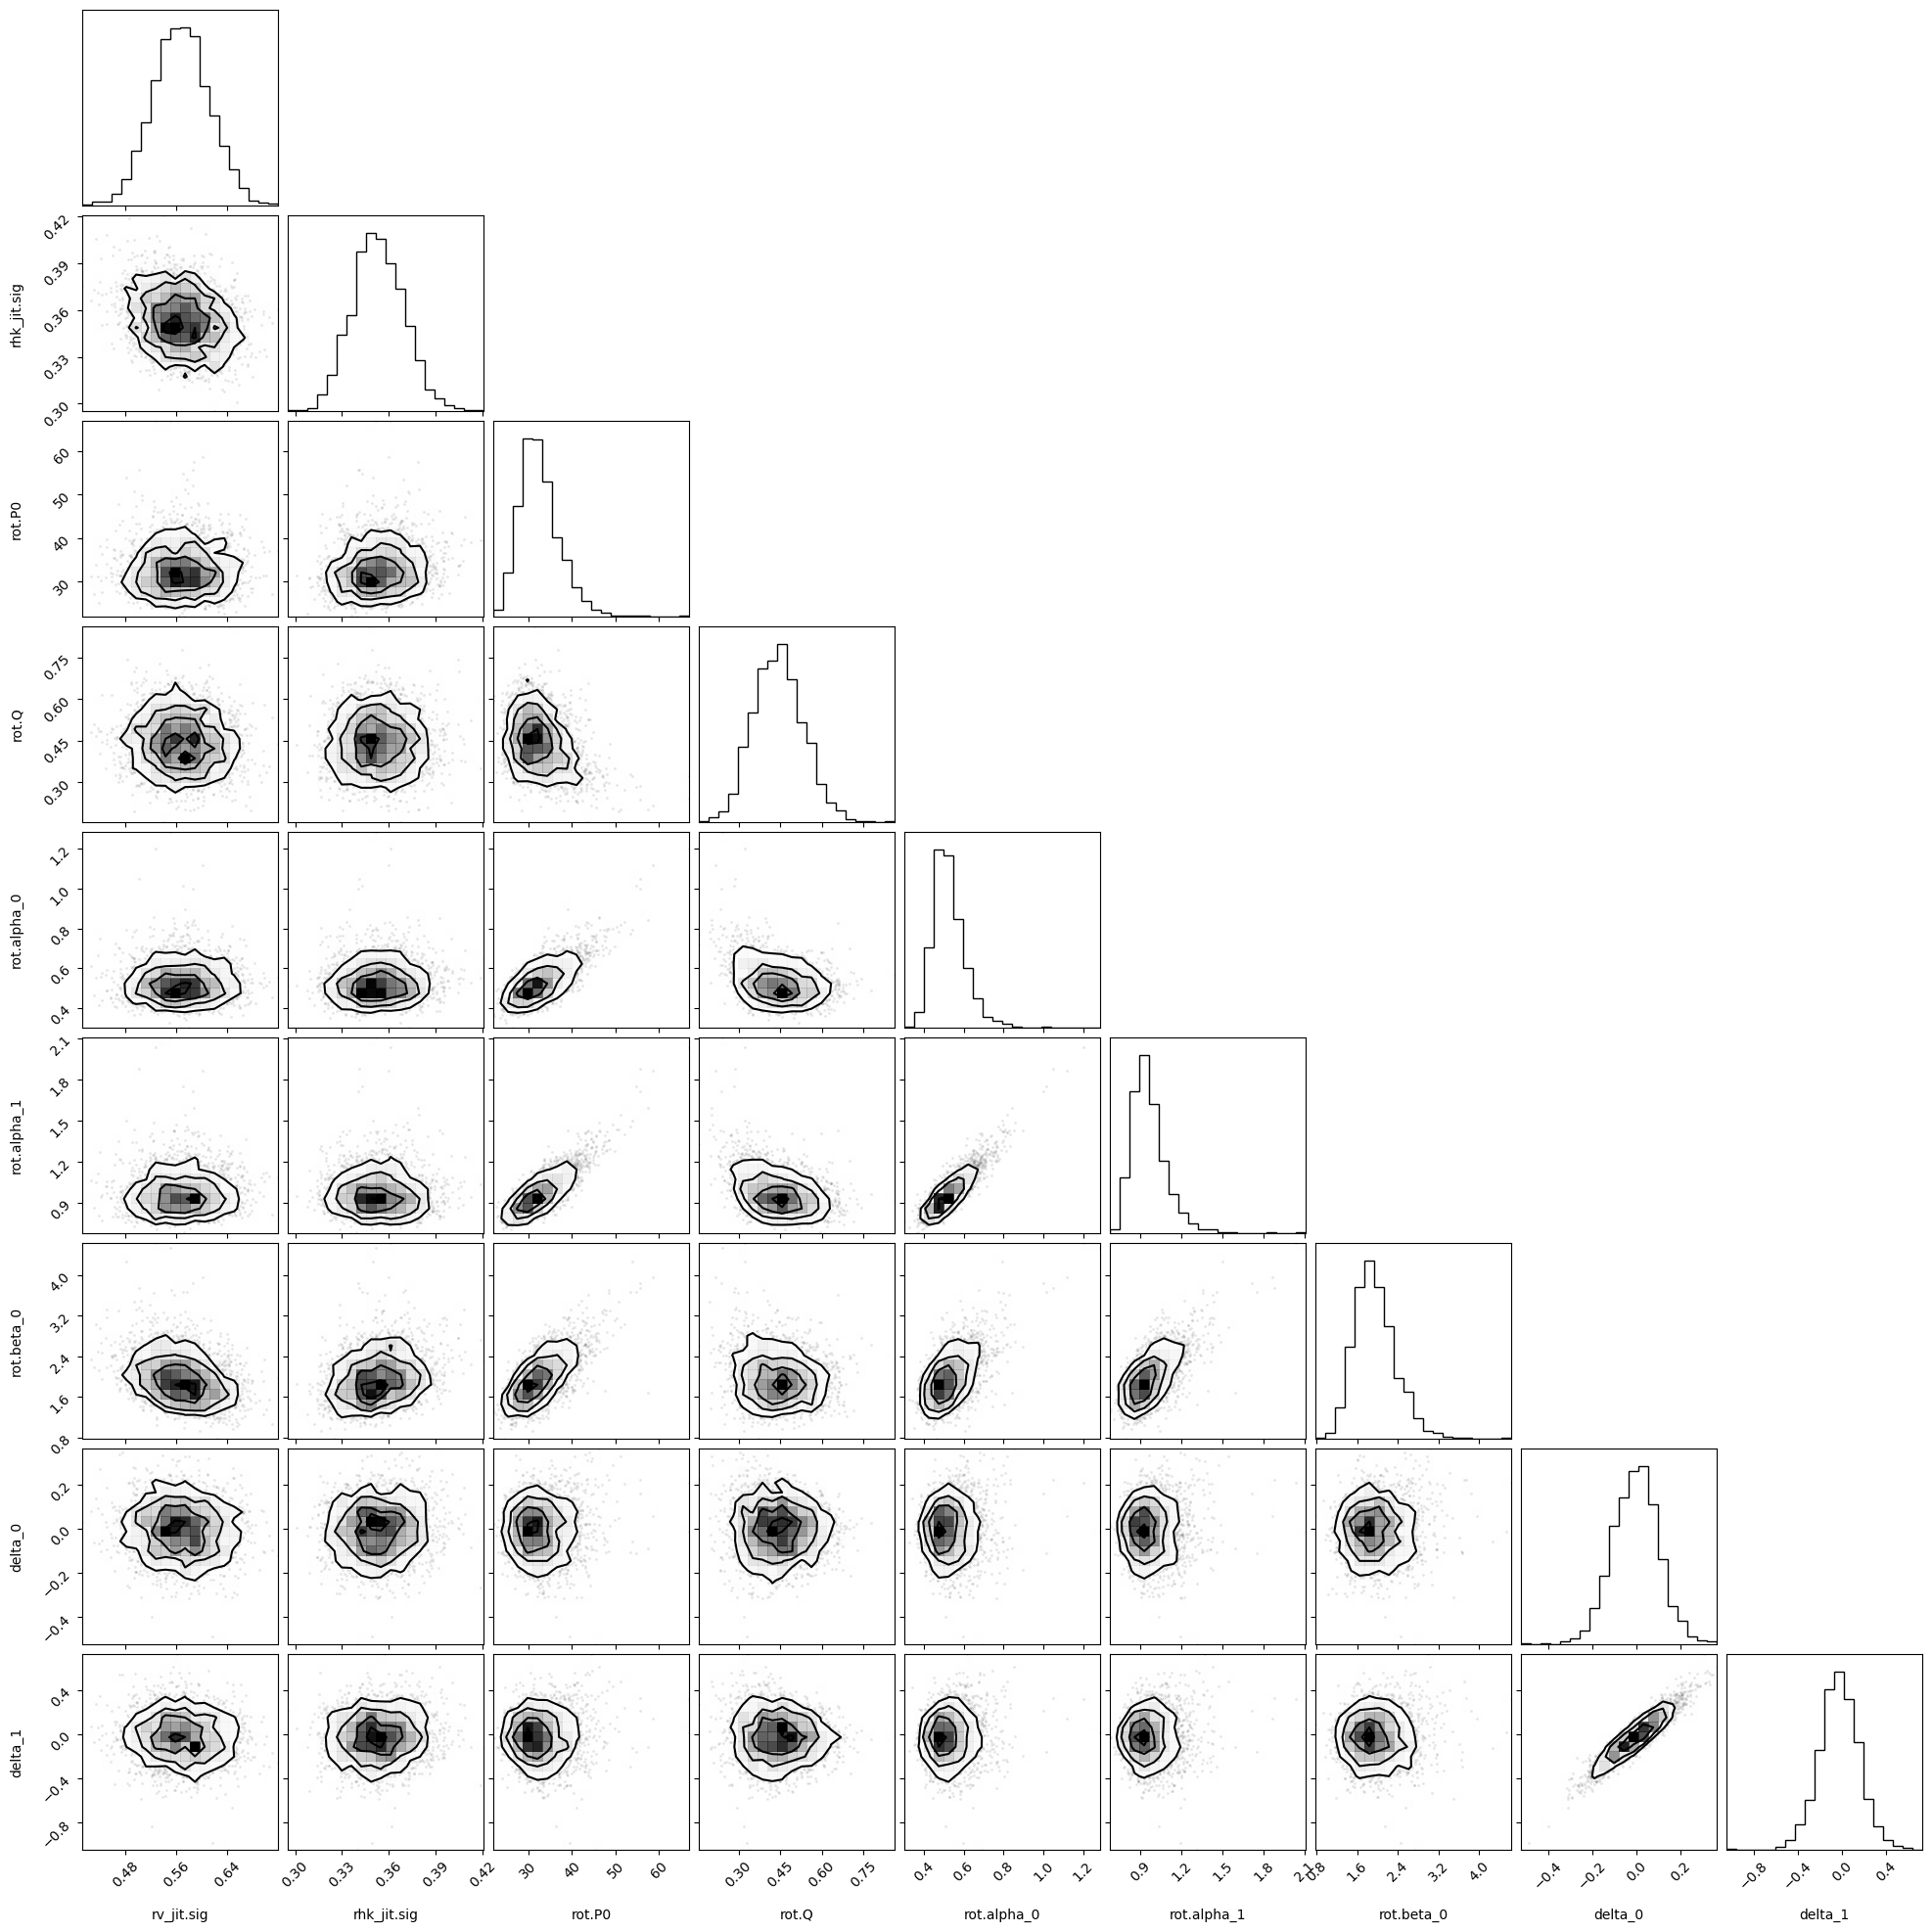

In [77]:
import corner

flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



In [78]:
burn = 1500 
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

# np.save("sun_map_sample_simpleGP_const_mean.npy", map_sample)

MAP index (in flattened, post-burn chain): 7462
MAP log-posterior: -992.701876989934
MAP sample (theta): [5.74454980e-01 3.56572980e-01 2.93619543e+01 4.19386467e-01
 4.64668910e-01 8.39033557e-01 1.73204048e+00 1.24334282e-02
 1.96126242e-02]


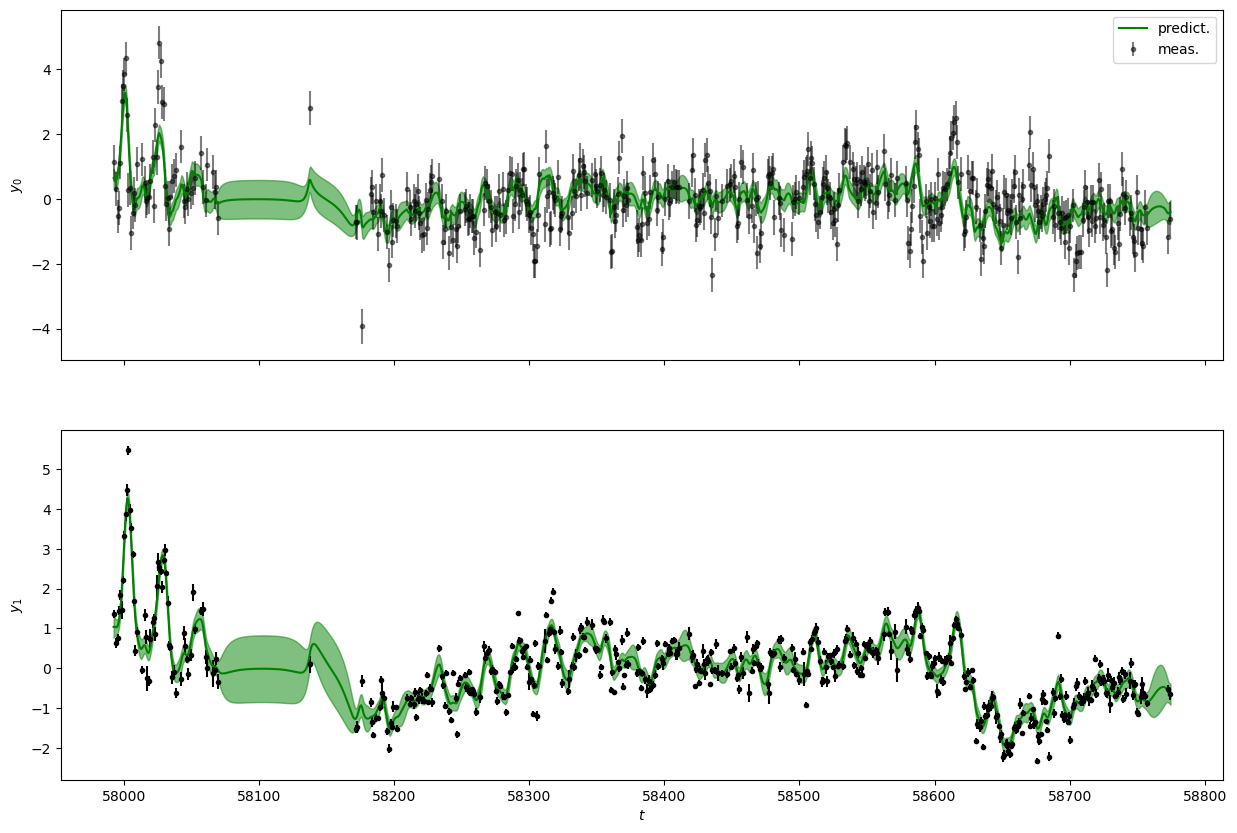

In [79]:
# map_sample = np.load("sun_map_sample_simpleGP_const_mean.npy")

C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])
C.set_param([np.var(y_full)], ['rot.sig'])


tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['rot'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  # use MAP sample for modulation and offsets
 
  y_model = y_full.copy()
  # map_sample tail: [..., gamma_0, gamma_1, delta_0, delta_1]
  y_model[series_index[0]] -=  map_sample[-2]
  y_model[series_index[1]] -=  map_sample[-1]
  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = y_model[series_index[k]] - mu_res
  else:
    res_rhk = y_model[series_index[k]] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-map_sample[-2], Yerr[k], fmt='.', color='k', label='meas.',alpha=0.5)
  if k == 1:
    ax.errorbar(T[k], Y[k]-map_sample[-1], Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

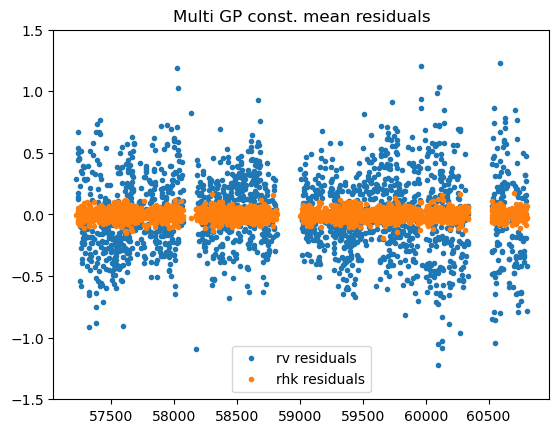

In [68]:
plt.figure()
plt.title("Multi GP const. mean residuals")
plt.plot(T[0], res_rv, ".", label='rv residuals')
plt.plot(T[1], res_rhk, ".", label='rhk residuals')
plt.ylim(-1.5,1.5)
plt.legend()
plt.show()

In [69]:
# map_sample = np.load("sun_map_sample_simpleGP_const_mean.npy")

rv_jit, rhk_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, delta_0, delta_1 = map_sample

res_rv = 0
res_rhk = 0

rv_true = []
rv_pred = []
rv_var = []
# rv_means = []

rhk_true = []
rhk_pred = []
rhk_var = []
# rhk_means = []

t_is = []


    # now loop over points *in series k* and leave each one out
for local_i in range(len(T[0])-3):

    T_train = np.delete(T, [local_i, local_i+1], axis=1)
    Y_train = np.delete(Y, [local_i, local_i+1], axis=1)
    Yerr_train = np.delete(Yerr, [local_i, local_i+1], axis=1)

    t_train_full, y_train_full, yerr_train_full, series_index_train_full = cov.merge_series(T_train, Y_train, Yerr_train)

    y_model_train_full = y_train_full.copy()
    y_model_train_full[series_index_train_full[0]] -= map_sample[-2]
    y_model_train_full[series_index_train_full[1]] -= map_sample[-1]
        
    t_i = T[0][local_i:local_i+2]  
    rv_i = Y[0][local_i:local_i+2] - map_sample[-2]
    rhk_i = Y[1][local_i:local_i+2] - map_sample[-1]

    # print(rv_i==y_model[series_index[0][local_i:local_i+2]])
    t_is.append(t_i)
    rv_true.append(rv_i)
    rhk_true.append(rhk_i)

    C = cov.Cov(
    t_train_full,
    err=term.Error(yerr_train_full),
    rv_jit=term.InstrumentJitter(series_index_train_full[0], rv_jit),
    rhk_jit=term.InstrumentJitter(series_index_train_full[1], rhk_jit),
    rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index_train_full, 
    np.ones(2) * stds, 
    np.array([stds[0], 0.0])
        ),
    )

    C.set_param(map_sample[:len(params)], params)
    C.set_param([0.0], ['rot.beta_1'])
    C.set_param([np.var(y_full)], ['rot.sig'])

    for k in range(2):

        C.kernel['rot'].set_conditional_coef(series_id=k)
        # Condition on training targets (with the single point removed) and predict at t_i
        mu_i, var_i = C.conditional(y_model_train_full, t_i, calc_cov='diag')
        # store the predicted mean/var for this held-out point
        
        if k == 0:
            rv_pred.append(mu_i)
            rv_var.append(var_i)
            resid = rv_i - mu_i
            res_rv += np.sum(resid ** 2)
        else:
            rhk_pred.append(mu_i)
            rhk_var.append(var_i)
            resid = rhk_i - mu_i
            res_rhk += np.sum(resid ** 2)


print(f"LOO residual sum of squares for RV: {res_rv:.4f}")
print(f"LOO residual sum of squares for RHK: {res_rhk:.4f}")

LOO residual sum of squares for RV: 482.3091
LOO residual sum of squares for RHK: 44.1986
